In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
uploaded = files.upload()

Saving combats.csv to combats.csv
Saving pokemon.csv to pokemon.csv
Saving tests.csv to tests.csv


In [2]:
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")
tests = pd.read_csv("tests.csv")

print("Pokemon shape:", pokemon.shape)
print("Combats shape:", combats.shape)
print("Tests shape:", tests.shape)

pokemon.head()

Pokemon shape: (800, 12)
Combats shape: (50000, 3)
Tests shape: (10000, 2)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
# Розмір та інформація
print(pokemon.shape)
print(pokemon.info())
print(pokemon.describe())

(800, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB
None
              #          HP      Attack     Defense     Sp. Atk     Sp. Def  \
count  800.0000  800.000000  800.000000  800.000000  800.000000  800.000000   
mean   400.5000   69.258750   79.001250   73.842500   72.820000   71.902500   
std    231.0844   25.53

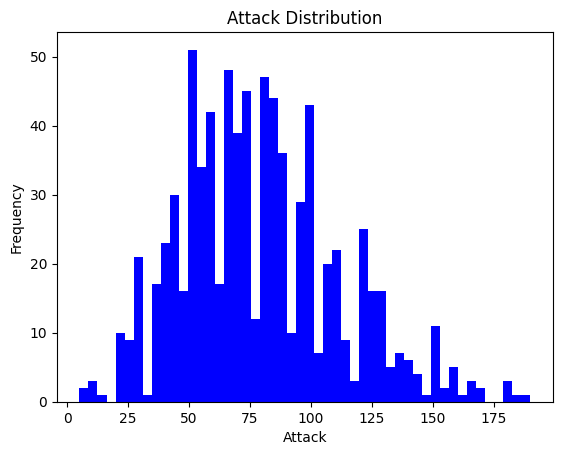

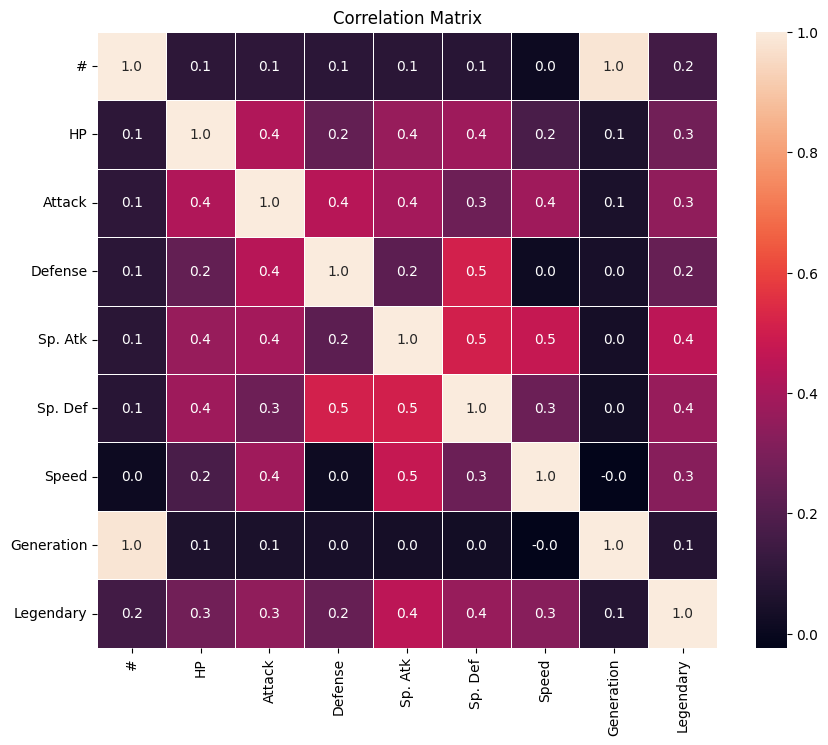

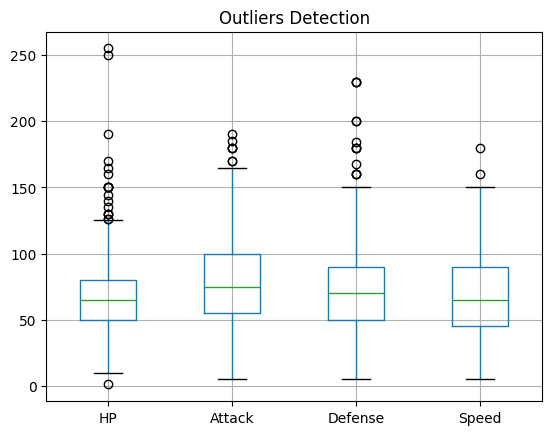

In [4]:
# Гістограма розподілу Attack
pokemon["Attack"].plot(kind="hist", bins=50, title="Attack Distribution", color="blue")
plt.xlabel("Attack")
plt.show()

# Кореляційна матриця
f, ax = plt.subplots(figsize=(10, 8))
corr = pokemon.corr(numeric_only=True)
sns.heatmap(corr, linewidths=0.5, ax=ax, annot=True, fmt=".1f")
plt.title("Correlation Matrix")
plt.show()

# Boxplot для виявлення викидів
pokemon.boxplot(column=["HP", "Attack", "Defense", "Speed"])
plt.title("Outliers Detection")
plt.show()

In [5]:
# Перевірка пустих значень
print(pokemon.isnull().sum())

# Заповнення пустих значень у колонці Type 2
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

# Перевірка після заповнення
print(pokemon.isnull().sum())

# Перевірка дублікатів
print("Дублікати:", pokemon.duplicated().sum())

# Видалення рядків з пустими значеннями (якщо залишились)
pokemon_cleaned = pokemon.dropna()
print("Розмір після очищення:", pokemon_cleaned.shape)

#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64
Дублікати: 0
Розмір після очищення: (799, 12)
